## Load EEG and preprocesses in same fashion as Alice dataset

Loads EEG data from data_preprocessed but adds preprocessing steps to align with preprocessing of Alice dataset.

In [1]:
import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import eelbrain
import mne
import numpy as np
import scipy.io


SUBJECTS = helper_functions.get_subjects()

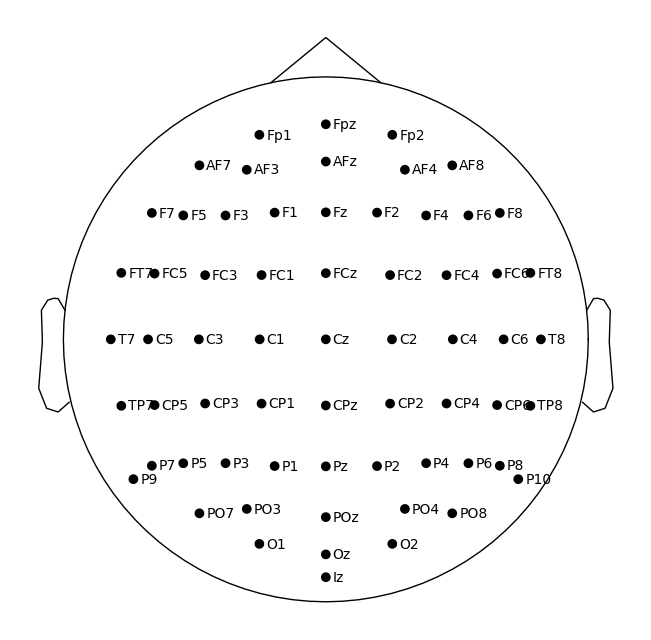

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 64 EEG, 2 misc
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 32.0 Hz
 meas_date: unspecified
 nchan: 66
 projs: []
 sfreq: 64.0 Hz
>

In [2]:
samplingrate = 64

# Create Biosemi montage with mastoids
montage = mne.channels.make_standard_montage('biosemi64')
montage.plot()
ch_names = montage.ch_names + ['EXG1', 'EXG2']  # include mastoids
ch_types = ['eeg'] * 64 + ['misc', 'misc']  # mastoids are misc
info = mne.create_info(ch_names, samplingrate, ch_types)
info.set_montage(montage, on_missing='ignore')  # mastoids not in standard montage

In [3]:
for SUB in SUBJECTS:

    dst_dir = file_paths.EEG_DIR / SUB
    dst_dir.mkdir(exist_ok=True, parents=True)
    eeg_dst = dst_dir / f"{SUB}_eeg.pickle"
    eeg_padded_dst = dst_dir / f"{SUB}_eeg_padded.pickle"
    if eeg_dst.exists() and eeg_padded_dst.exists():
        print(f"{SUB} already processed, skipping")
        continue

    # --- Load MATLAB data ---
    mat = scipy.io.loadmat(f"{file_paths.DATA_PREPROC}/{SUB}_data_preproc.mat", squeeze_me=True, struct_as_record=False)
    data = mat["data"]

    eeg_trials = []
    eeg_padded_trials = []

    for trial in data.eeg:
        # Channels × time
        eeg = np.array(trial).T
        raw = mne.io.RawArray(eeg * 1e-6, info, verbose=False)  # convert µV → V

        # Preprocessing
        raw.set_eeg_reference(['EXG1', 'EXG2'])      # average mastoids
        raw.filter(0.5, 20, verbose=False)           # band-pass

        # Convert to NDVar
        eeg_ndvar = eelbrain.load.mne.raw_ndvar(raw)      # automatically handles time & sensor axes
        eeg_trials.append(eeg_ndvar)

        # Save the padded eeg as well
        padded_eeg = eelbrain.pad(eeg_ndvar, tstart=-0.100, tstop=eeg_ndvar.time[-1] + 1)
        eeg_padded_trials.append(padded_eeg)


        

    # Concatenate trials
    eeg_all = eelbrain.concatenate(eeg_trials)
    eeg_padded_all = eelbrain.concatenate(eeg_padded_trials)
    eelbrain.save.pickle(eeg_all, eeg_dst)
    eelbrain.save.pickle(eeg_padded_all, eeg_padded_dst)
    
    print(f"Saved preprocessed EEG for {SUB}")

Saved preprocessed EEG for S1
Saved preprocessed EEG for S2
Saved preprocessed EEG for S3
Saved preprocessed EEG for S4
Saved preprocessed EEG for S5
Saved preprocessed EEG for S6
Saved preprocessed EEG for S7
Saved preprocessed EEG for S8
Saved preprocessed EEG for S9
Saved preprocessed EEG for S10
Saved preprocessed EEG for S11
Saved preprocessed EEG for S12
Saved preprocessed EEG for S13
Saved preprocessed EEG for S14
Saved preprocessed EEG for S15
Saved preprocessed EEG for S16
Saved preprocessed EEG for S17
Saved preprocessed EEG for S18


In [5]:
# Sanity check: load one of the saved files and print its shape
eeg = eelbrain.load.unpickle(file_paths.EEG_DIR / "S1" / "S1_eeg.pickle")
print(eeg)

<NDVar: 64 sensor, 192000 time>
